In [65]:
# STEP 1: import libraries
import os
import pandas as pd
import numpy as np



In [66]:
 # step 2: Random Seed
np.random.seed(42)
print('seed set!')

seed set!


In [67]:
# Step 3: aircraft type

aircraft_types = [
    "F-35A", "F-35B", "F-35C",
    "C-130J", "CH-53K", "UH-60M",
    "AH-64E", "F-22A", "B-1B", "E-3 Sentry"
]

print(aircraft_types)
print("Total Types:",len(aircraft_types))

['F-35A', 'F-35B', 'F-35C', 'C-130J', 'CH-53K', 'UH-60M', 'AH-64E', 'F-22A', 'B-1B', 'E-3 Sentry']
Total Types: 10


In [68]:
# step 4 : bases

bases= [
    "Edwards AFB CA",
    "Eglin AFB FL",
    "Nellis AFB NV",
    "Langley AFB VA",
    "Hill AFB, UT "
]
print(bases)
print("Total Bases:",len(bases))

['Edwards AFB CA', 'Eglin AFB FL', 'Nellis AFB NV', 'Langley AFB VA', 'Hill AFB, UT ']
Total Bases: 5


In [69]:
# step 5 : Maintenance type

maintenance_types = [
    "Engine Inspection",
    "Avionics Check",
    "Landing Gear Service",
    "Hydraulic System Repair",
    "Structural Inspection",
    "Fuel System Check",
    "Tire & Brake Replacement",
    "Software Update"
]

print(maintenance_types)
print("Total Maintenance Types:",len(maintenance_types))

['Engine Inspection', 'Avionics Check', 'Landing Gear Service', 'Hydraulic System Repair', 'Structural Inspection', 'Fuel System Check', 'Tire & Brake Replacement', 'Software Update']
Total Maintenance Types: 8


In [70]:
# step 6: statuses

statuses = ["complete", "pending","in_progress","failed"]
status_weights = [0.68,0.12,0.12,0.08]
print(statuses)
print("weights",status_weights)
print("Sum of weights:",sum(status_weights))

['complete', 'pending', 'in_progress', 'failed']
weights [0.68, 0.12, 0.12, 0.08]
Sum of weights: 1.0


When Numpy randlomly assigns a status to each of our 50,000 log rows it uses these weights to decide. So instead of picking statuses randlomly (25% of each ) , it picks them reakistically mostly complte , rarely failed.
Without weights every status would appear equally. That's not realistic. A databases where 25% of all flights fail would never happean in real life.

Exact weights are - just written as decimals instead of percentage

68 out of 1000 = 0.68

12 out of 100 = 0.12


12 out of 100 = 0.12


8 out of 100 = 0.08   




total = 1.00


In [71]:
# step 7: cost ranges

# this one is slightly different as it is not a list . It's a dictionary

cost_ranges = {
    "Engine Inspection"      : (8000,  25000),  # physical labor + specilaized tools  + possible parts replacements + hr of works =  different cost
    "Avionics Check"         : (5000,  15000),
    "Landing Gear Service"   : (3000,  12000),
    "Hydraulic System Repair": (4000,  18000),
    "Structural Inspection"  : (2000,  10000),
    "Fuel System Check"      : (1500,   6000),
    "Tire & Brake Replacement": (800,   5000),
    "Software Update"        : (500,    3000),   #     laptop + techncial knowledge + 1-2 hrs  = different cost
}
print(cost_ranges)

{'Engine Inspection': (8000, 25000), 'Avionics Check': (5000, 15000), 'Landing Gear Service': (3000, 12000), 'Hydraulic System Repair': (4000, 18000), 'Structural Inspection': (2000, 10000), 'Fuel System Check': (1500, 6000), 'Tire & Brake Replacement': (800, 5000), 'Software Update': (500, 3000)}


**What do the two numbers in (8000 , 25000)represent ?**


Every Engine Inspection job will cost somewhere between $8000 to $25000 where numpy will pick a random number in that range for each log row


We still need Technician Names and Departments. We'll do those with Faker later


In [72]:
#step 8 : Set the size of our dataset

N_AIRCRAFT = 150          # everyplaces that uses N_AIRCRAFT automatically updates.
N_TECHNICIANS = 200
N_LOGS = 50000

print("Aircraft:",N_AIRCRAFT)
print("Technicians:",N_TECHNICIANS)
print("Logs:",N_LOGS)



Aircraft: 150
Technicians: 200
Logs: 50000


In [73]:
# step 9:
aircraft_ids = [f"AC-{str(i).zfill(4)}" for i in range(1, N_AIRCRAFT + 1)]

print(aircraft_ids[:5])
print("Total aircraft:", len(aircraft_ids))


['AC-0001', 'AC-0002', 'AC-0003', 'AC-0004', 'AC-0005']
Total aircraft: 150


We build the blocks and they are just lists sitting in memory rightnow . They are not connected to each other. They don't look like a table.



Using Pd.DataFrame ({............}) takes all those seperate  lists and organized them into rows and columns like an excel sheet.


The Dictionary {....} inside tell pandas:

{
  "aircraft_id" : aircraft_ids,  # columns name : data
  "aircraft_type" : np.random.choice(),  # column name : data
  "bases" : np.random.choice(), # column name : data
}



In left side = column name and right side = the data that fills that column



Column A header = 'aircraft_id'  >>>>>>>>>>> fill with aircraft_ids lists


Column B header = 'aircraft_type' >>>>>>>>>> fill with random choices from aircraft_types


Column C header = "base" >>>>>>>>>>>>>>>>>> fill with random choices from bases



In [74]:
# Step 10:
aircraft_df = pd.DataFrame({
    "aircraft_ids"       : aircraft_ids,
    "aircraft_type"      : np.random.choice(aircraft_types, size=N_AIRCRAFT),
    "base"               : np.random.choice(bases, size=N_AIRCRAFT),
    "year_built"         : np.random.randint(2000,2023, N_AIRCRAFT),
    "total_flight_hours" : np.random.randint(100,1200, N_AIRCRAFT)
})
print(aircraft_df.head())

  aircraft_ids aircraft_type            base  year_built  total_flight_hours
0      AC-0001        AH-64E   Nellis AFB NV        2020                1166
1      AC-0002        C-130J   Nellis AFB NV        2022                 384
2      AC-0003         F-22A  Edwards AFB CA        2000                 496
3      AC-0004        CH-53K   Hill AFB, UT         2002                 111
4      AC-0005        AH-64E  Edwards AFB CA        2017                 598


np.random.choice(aircraft_types, N_AIRCRAFT)   >>>>>>>>>>>>>> randomly picks 150 aircraft types from our list

np.ransom.randint(2000,2023, N_AIRCRAFT) >>>>>>>>>>>>>>>>>>> randomly picks 150 yeards between 2000 to 2023

In [75]:
 # step 11:
print(aircraft_df.shape)

(150, 5)


In [76]:
# step 12:
print(type(aircraft_df))

<class 'pandas.core.frame.DataFrame'>


(150, 5) means:

150 >> 150 rows (one per aircraft)




5   >> 5 coumns( aircraft_id, aircraft_type, base, year_build, total_flight_hours)

.head() is how analyst quickly sanity check their data .

In [77]:
# step13: adding column age year

aircraft_df['age_year'] = 2024 - aircraft_df['year_built']
print(aircraft_df.head())

  aircraft_ids aircraft_type            base  year_built  total_flight_hours  \
0      AC-0001        AH-64E   Nellis AFB NV        2020                1166   
1      AC-0002        C-130J   Nellis AFB NV        2022                 384   
2      AC-0003         F-22A  Edwards AFB CA        2000                 496   
3      AC-0004        CH-53K   Hill AFB, UT         2002                 111   
4      AC-0005        AH-64E  Edwards AFB CA        2017                 598   

   age_year  
0         4  
1         2  
2        24  
3        22  
4         7  


In [78]:
 # step 14: adding wear score column

aircraft_df['wear_score'] = round(
    (aircraft_df['total_flight_hours'] / 12000 *0.6 ) +
    (aircraft_df['age_year'] /24 * 0.4),3 )

print(aircraft_df.head())

  aircraft_ids aircraft_type            base  year_built  total_flight_hours  \
0      AC-0001        AH-64E   Nellis AFB NV        2020                1166   
1      AC-0002        C-130J   Nellis AFB NV        2022                 384   
2      AC-0003         F-22A  Edwards AFB CA        2000                 496   
3      AC-0004        CH-53K   Hill AFB, UT         2002                 111   
4      AC-0005        AH-64E  Edwards AFB CA        2017                 598   

   age_year  wear_score  
0         4       0.125  
1         2       0.053  
2        24       0.425  
3        22       0.372  
4         7       0.147  


total_flight_hours/ 12000   

If an aircraft flown 6000 hours out of a maximum 12000:

6000/12000 = 0.5

0.5 means the aicraft has 50% of its total life.

age-years /24

12/24 = 0.5

again 0.5 means it's halfway thorugh its lifespan


the weights 0.6 and 0.4
flight hrs contribute 60 % to wear
age contributes 40 % to wear

wear_score = (how much of flight life used * 60% ) + ( how much of age life used * 40%)

0 >>>>>>>>>>>>>>>> brand new , barely used
1 >>>>>>>>>>>>>>>> completely worn out

In [79]:
# step 15 :

tech_id = [f"TECH-{str(i).zfill(4)}" for i in range(1, N_TECHNICIANS + 1)]
print(tech_id[:5])
print("Total Techs:", len(tech_id))

['TECH-0001', 'TECH-0002', 'TECH-0003', 'TECH-0004', 'TECH-0005']
Total Techs: 200


In [80]:
# step 16 :

cert_levels = ["Level 1", "Level 2", "Level 3","Lead Technician", "Senior Technician"]
cert_weights = [0.25,0.30,0.25,0.12,0.08]
print(cert_levels)
print("sum of weights",sum(cert_weights))

['Level 1', 'Level 2', 'Level 3', 'Lead Technician', 'Senior Technician']
sum of weights 1.0


**Why does level 2 have the highest weight of 0.30 ? **


It is because very few people reach the top , Most people are in the middle (level 2, level 3 ) and some are just starting out (level 1)

Most people sit in the middle that's why level 2 has the highest weight

In [81]:
#step 17: dept and hr rates

departments =  ["AirFrame","Propulsion","Avionics","Weapons Systems", "Hydraulics","Electrical","Life Support"]

cert_rate_map = {
    "Level 1"           : 45,
    "Level 2"           : 60,
    "Level 3"           : 80,
    "Lead Technician"   : 100,
    "Senior Technician" : 130
}

print(departments)
print(cert_rate_map)


['AirFrame', 'Propulsion', 'Avionics', 'Weapons Systems', 'Hydraulics', 'Electrical', 'Life Support']
{'Level 1': 45, 'Level 2': 60, 'Level 3': 80, 'Lead Technician': 100, 'Senior Technician': 130}


In [82]:
# Step 18 : Building technician tables

cert_assigned = np.random.choice(
    cert_levels,
    p=cert_weights,
    size=N_TECHNICIANS )

technicians_df = pd.DataFrame({
    "technician_id"             : tech_id,
    "department"          : np.random.choice(departments,N_TECHNICIANS),
    "certification_level" : cert_assigned,
    "years_experience "   : np.random.randint(0,20, N_TECHNICIANS),
    "base"                : np.random.choice(bases, N_TECHNICIANS),
    "active"              : np.random.choice([1,0],N_TECHNICIANS,p=[0.92,0.08])
})
technicians_df['hourly_rate'] = technicians_df['certification_level'].map(cert_rate_map)
print(technicians_df.head())
print("\nshape", technicians_df.shape)


  technician_id    department certification_level  years_experience   \
0     TECH-0001      AirFrame             Level 3                  2   
1     TECH-0002      AirFrame     Lead Technician                 19   
2     TECH-0003      AirFrame             Level 1                 10   
3     TECH-0004      Avionics     Lead Technician                  5   
4     TECH-0005  Life Support             Level 3                  1   

             base  active  hourly_rate  
0   Hill AFB, UT        1           80  
1  Langley AFB VA       1          100  
2  Langley AFB VA       1           45  
3   Nellis AFB NV       1          100  
4    Eglin AFB FL       1           80  

shape (200, 7)


In [83]:
# step 19 : log id
log_id = [f"LOG-{str(i).zfill(5)}" for i in range(1, N_LOGS + 1)]
print(log_id[:5])
print("Total logs:", len(log_id))

['LOG-00001', 'LOG-00002', 'LOG-00003', 'LOG-00004', 'LOG-00005']
Total logs: 50000


In [84]:
# step 20 : Generating the dates

import numpy as np
import pandas as pd

log_dates = pd.date_range(start='2021/01/01', end='2023/12/31', periods = N_LOGS)
print(log_dates[:5])
print("Total dates:", len(log_dates))

DatetimeIndex([          '2021-01-01 00:00:00',
               '2021-01-01 00:31:30.469809396',
               '2021-01-01 01:03:00.939618792',
               '2021-01-01 01:34:31.409428188',
               '2021-01-01 02:06:01.879237584'],
              dtype='datetime64[ns]', freq=None)
Total dates: 50000


In [85]:
# step 21:  randomly assign aircraft, technicians and maintenance types to each log.

selected_aircrafts = np.random.choice(aircraft_ids, size=N_LOGS)
selected_technicians = np.random.choice(tech_id, size=N_LOGS)
selected_maint = np.random.choice(maintenance_types, size=N_LOGS)
selected_statuses = np.random.choice(statuses, size=N_LOGS, p=status_weights)

print(selected_aircrafts[:5])
print(selected_technicians[:5])
print(selected_maint[:5])
print(selected_statuses[:5])

['AC-0024' 'AC-0148' 'AC-0037' 'AC-0004' 'AC-0108']
['TECH-0170' 'TECH-0090' 'TECH-0139' 'TECH-0072' 'TECH-0067']
['Avionics Check' 'Avionics Check' 'Software Update'
 'Landing Gear Service' 'Hydraulic System Repair']
['complete' 'complete' 'complete' 'complete' 'failed']


**Why do selected_statuses use p=status_weights but the others don't?**


It is because we want each aircraft, technician, and maintenance type to be chosen equally randomly. No aircraft is more likely to appear than another. No technician gets more jobs than another by default.

selected_statuses — needs weights
Without weights every status would appear 25% of the time — unrealistic.



Picking a random aircraft = flipping a fair coin — equal chance for everyone.
Picking a random status = weighted dice — some outcomes happen more than others.

In [86]:
# step 22: Generating costs

costs = [
    int(np.random.uniform(cost_ranges[str(m)][0], cost_ranges[str(m)][1]))
    for m in selected_maint
]

print("Total costs generated:", len(costs))
print("Sample costs:", costs[:5])
print("Min cost:", min(costs))
print("Max cost:", max(costs))

Total costs generated: 50000
Sample costs: [6638, 11213, 2666, 4857, 5792]
Min cost: 500
Max cost: 24998


**Using uniform gives us that realistic decimal behavior.**


While randint gives us whole number.




The reason we used uniform is it gives a smoother distribution — every value between 8000 and 25000 is equally possible, including decimals.
With randint only whole numbers are possible — still 17,000 possible values, so practically the same.

**Why uniform over randint?**


Uniform gives a continuous distribution including decimals, which better mimics real invoice amounts. Randint works too but limits us to whole numbers only.



For each maintenance type in selected_maint, look up its cost range, pick a random decimal number between min and max, then convert to a whole number.

In [87]:
# step 23 : generate Durations
durations = []

for s in selected_statuses:
    if s == "complete":
        durations.append(round(np.random.uniform(1, 16), 1))
    elif s == "failed":
        durations.append(round(np.random.uniform(10, 72), 1))
    elif s == "in_progress":
        durations.append(round(np.random.uniform(4, 32), 1))
    else:
        durations.append(round(np.random.uniform(2, 20), 1))
print(durations[:5])
print("Total durations generated:", len(durations))
print("Sample durations:", durations[:5])
print("Min duration:", min(durations))
print("Max duration:", max(durations))


[8.5, 13.4, 5.6, 9.8, 61.3]
Total durations generated: 50000
Sample durations: [8.5, 13.4, 5.6, 9.8, 61.3]
Min duration: 1.0
Max duration: 72.0


**Why do failed jobs take 10-72 hours but complete jobs only take 1-16 hours?**


-- When a job fails:

Technician has to diagnose what went wrong
May need to order emergency parts
Supervisor gets involved
Extra inspections and sign-offs required
Sometimes the whole job starts over

-- When a job completes normally:

Routine work, known steps
Parts already available
1-16 hours and done

In [88]:
# step 24:

parts_replaced = np.random.randint(0, 12, N_LOGS)

print("Sample parts replaced:", parts_replaced[:5])
print("Min:", min(parts_replaced))
print("Max:", max(parts_replaced))

Sample parts replaced: [3 4 4 7 3]
Min: 0
Max: 11


**Why does parts_replaced start from 0 and not 1?**


Not every maintenance job requires replacing a part — Software Update or Structural Inspection might replace 0 parts.

In [89]:
# step 25 :
notes_pool = [
    "Routine check completed successfully",
    "Replaced worn components — within tolerance",
    "Issue found during inspection — escalated",
    "Emergency repair required — grounded aircraft",
    "Scheduled maintenance — no anomalies",
    "Follow-up inspection required within 30 days",
    "All systems nominal post-maintenance",
    "Part ordered — awaiting delivery",
    None,
    None,
    None
]

notes = np.random.choice(notes_pool, N_LOGS)

print("Sample notes:", notes[:5])

Sample notes: [None 'Replaced worn components — within tolerance' None
 'Emergency repair required — grounded aircraft'
 'Follow-up inspection required within 30 days']


**Why did we put None three times in the notes_pool list?**


notes_pool has 11 items total:

8 real notes
3 None values
─────────────
11 items total

When numpy randomly picks from this list — each item has equal chance of being picked:

chance of getting a real note  = 8/11 = 73%
chance of getting None         = 3/11 = 27%

So roughly 27% of logs will have no notes — the technician didn't write anything.


Why is that realistic?
In real life:

Busy technicians skip writing notes
Routine jobs often get no notes
Only important or unusual jobs get documented

If every single row had a note — that wouldn't be realistic.




In [90]:
# step 26 :
maintenance_logs_df = pd.DataFrame({
    "log_id"             : log_id,
    "aircraft_id"        : selected_aircrafts,
    "technician_id"      : selected_technicians,
    "maintenance_type"   : selected_maint,
    "status"             : selected_statuses,
    "cost_usd"           : costs,
    "duration_hours"     : durations,
    "log_date"           : pd.to_datetime(log_dates).strftime("%Y-%m-%d"),
    "parts_replaced"     : parts_replaced,
    "notes"              : notes,
})

print(maintenance_logs_df.head())
print("\nShape:", maintenance_logs_df.shape)

      log_id aircraft_id technician_id         maintenance_type    status  \
0  LOG-00001     AC-0024     TECH-0170           Avionics Check  complete   
1  LOG-00002     AC-0148     TECH-0090           Avionics Check  complete   
2  LOG-00003     AC-0037     TECH-0139          Software Update  complete   
3  LOG-00004     AC-0004     TECH-0072     Landing Gear Service  complete   
4  LOG-00005     AC-0108     TECH-0067  Hydraulic System Repair    failed   

   cost_usd  duration_hours    log_date  parts_replaced  \
0      6638             8.5  2021-01-01               3   
1     11213            13.4  2021-01-01               4   
2      2666             5.6  2021-01-01               4   
3      4857             9.8  2021-01-01               7   
4      5792            61.3  2021-01-01               3   

                                           notes  
0                                           None  
1    Replaced worn components — within tolerance  
2                            

In [91]:
# step 27 : Save into csv
aircraft_df.to_csv("aircraft.csv", index=False)
technicians_df.to_csv("technicians.csv", index=False)
maintenance_logs_df.to_csv("maintenance_logs.csv", index=False)

print("Files saved!")
print("aircraft.csv        —", len(aircraft_df), "rows")
print("technicians.csv     —", len(technicians_df), "rows")
print("maintenance_logs.csv—", len(maintenance_logs_df), "rows")

Files saved!
aircraft.csv        — 150 rows
technicians.csv     — 200 rows
maintenance_logs.csv— 50000 rows


**Phase 2 — Data Munging & Cleaning**

In [92]:
# Phase 2 — Step 1: Explore the data
print("Shape:", maintenance_logs_df.shape)
print("\nColumn types:\n", maintenance_logs_df.dtypes)
print("\nMissing values:\n", maintenance_logs_df.isnull().sum())

Shape: (50000, 10)

Column types:
 log_id               object
aircraft_id          object
technician_id        object
maintenance_type     object
status               object
cost_usd              int64
duration_hours      float64
log_date             object
parts_replaced        int64
notes                object
dtype: object

Missing values:
 log_id                  0
aircraft_id             0
technician_id           0
maintenance_type        0
status                  0
cost_usd                0
duration_hours          0
log_date                0
parts_replaced          0
notes               13439
dtype: int64


**notes → 13,449 missing out of 50,000**

That's 26.9% missing — makes sense because we put 3 None values in our notes pool out of 11 items = 27%.
Everything else = 0

In [93]:
 # step 2:
import numpy as np
# work on a copy  never destroy original data
messy_df = maintenance_logs_df.copy()
print("Original shape:", maintenance_logs_df.shape)
print("Messy copy shape:", messy_df.shape)

Original shape: (50000, 10)
Messy copy shape: (50000, 10)


In [94]:
# Step 3: Missing values in cost_usd

# randomly make 5% of costs null
null_idx = np.random.choice(messy_df.index, size=int(N_LOGS * 0.05), replace=False)
messy_df.loc[null_idx, "cost_usd"] = np.nan

print("Missing cost_usd values:", messy_df["cost_usd"].isnull().sum())

Missing cost_usd values: 2500


 **What does int(N_LOGS * 0.05) calculate? **




N_LOGS * 0.05
= 50000 * 0.05
= 2500

**So we're saying "make 5% of cost values missing"**



50,000 rows × 5% = 2,500 rows with missing cost

And int() just removes any decimals keeps it a whole number since you can't have half a row.


**Why 5%?**




In real world databases, missing data typically ranges from 1% to 10% depending on the system. 5% is realistic — not too clean, not too broken.

In [95]:
# Step 4: Duplicate rows.


# randomly duplicate 2% of rows

dup_idx = np.random.choice(messy_df.index, size=int(N_LOGS * 0.02), replace=False)
messy_df = pd.concat([messy_df, messy_df.loc[dup_idx]], ignore_index=True)

print("Original rows:", N_LOGS)
print("Rows after duplicates:", len(messy_df))
print("Duplicate rows added:", len(messy_df) - N_LOGS)

Original rows: 50000
Rows after duplicates: 51000
Duplicate rows added: 1000


**What does pd.concat do here?**


 pd.concat stacks two DataFrames on top of each other.



 Like copying rows from one Excel sheet and pasting them at the bottom of the same sheet.

In [96]:
# Step 5: Status typos
# inject typos into status column
typo_idx = np.random.choice(messy_df.index, size=200, replace=False)
messy_df.loc[typo_idx, "status"] = np.random.choice(
    ["Complete", "COMPLETE", "complet", "Pending", "PENDING", "Failed", "FAILED"],
    size=200
)

print("Unique status values now:")
print(messy_df["status"].unique())

Unique status values now:
['complete' 'failed' 'pending' 'Failed' 'in_progress' 'FAILED' 'Complete'
 'COMPLETE' 'complet' 'Pending' 'PENDING']


In [97]:
# Step 6:   Wrong data type (cost as string)
# store some costs as "$X,XXX" string format
messy_df["cost_usd"] = messy_df["cost_usd"].astype(object)

dollar_idx = np.random.choice(messy_df.index, size=int(N_LOGS * 0.03), replace=False)

for idx in dollar_idx:
    val = messy_df.at[idx, "cost_usd"]
    if pd.notna(val):
        try:
            messy_df.at[idx, "cost_usd"] = f"${int(float(val)):,}"
        except:
            pass

print("Sample cost values:")
print(messy_df["cost_usd"].sample(10).values)


Sample cost values:
[10060.0 4146.0 7812.0 11621.0 9016.0 4228.0 4141.0 690.0 7106.0 nan]


In [98]:
# Step 7: find rows where cost is stored as string
string_costs = messy_df[messy_df["cost_usd"].apply(lambda x: isinstance(x, str))]
print("Rows with string costs:", len(string_costs))
print("Sample string costs:", string_costs["cost_usd"].head().values)

Rows with string costs: 1425
Sample string costs: ['$5,487' '$4,994' '$7,536' '$11,399' '$10,405']


In [99]:
print("Shape:", messy_df.shape)
print("\nMissing values:\n", messy_df.isnull().sum())
print("\nUnique statuses:", messy_df["status"].unique())
print("\nDuplicate rows:", messy_df.duplicated().sum())

Shape: (51000, 10)

Missing values:
 log_id                  0
aircraft_id             0
technician_id           0
maintenance_type        0
status                  0
cost_usd             2551
duration_hours          0
log_date                0
parts_replaced          0
notes               13713
dtype: int64

Unique statuses: ['complete' 'failed' 'pending' 'Failed' 'in_progress' 'FAILED' 'Complete'
 'COMPLETE' 'complet' 'Pending' 'PENDING']

Duplicate rows: 940


In [100]:
#Step 8: remove duplicates


print("Before:", len(messy_df))

messy_df = messy_df.drop_duplicates()

print("After:", len(messy_df))
print("Rows removed:", 51000 - len(messy_df))

Before: 51000
After: 50060
Rows removed: 940


In [101]:
# Step 9: Clean status typos
# standardize all status values to lowercase
messy_df["status"] = messy_df["status"].str.lower().str.strip()

# fix the typo "complet" → "complete"
messy_df["status"] = messy_df["status"].replace("complet", "complete")

print("Unique statuses after cleaning:")
print(messy_df["status"].unique())
print("\nStatus counts:")
print(messy_df["status"].value_counts())

Unique statuses after cleaning:
['complete' 'failed' 'pending' 'in_progress']

Status counts:
status
complete       33875
in_progress     6113
pending         6012
failed          4060
Name: count, dtype: int64


**What does .str.lower() do and why do we also need .str.strip()?**


.str.lower() all lower letter
.str.strip() removes extra spaces from both sides of a string.

In [102]:
# step 10 :  Clean cost_usd string values.

def clean_cost(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, str):
        val = val.replace("$", "").replace(",", "")
        return float(val)
    return float(val)

messy_df["cost_usd"] = messy_df["cost_usd"].apply(clean_cost)

print("Cost data type:", messy_df["cost_usd"].dtype)
print("Sample costs:", messy_df["cost_usd"].head().values)
print("String costs remaining:", messy_df["cost_usd"].apply(lambda x: isinstance(x, str)).sum())

Cost data type: float64
Sample costs: [   nan 11213.    nan  4857.  5792.]
String costs remaining: 0


In [103]:
# step 11: Handle missing cost values

print("Missing costs before:", messy_df["cost_usd"].isnull().sum())

# fill missing costs with median cost per maintenance type
messy_df["cost_usd"] = messy_df.groupby("maintenance_type")["cost_usd"].transform(
    lambda x: x.fillna(x.median())
)

print("Missing costs after:", messy_df["cost_usd"].isnull().sum())
print("\nSample costs:")
print(messy_df["cost_usd"].head(10).values)

Missing costs before: 2500
Missing costs after: 0

Sample costs:
[ 9982.  11213.   1729.5  4857.   5792.  18732.   2775.  22764.   5487.
  4024. ]


**Why did you use median instead of mean?**


Because median is not affected by outliers. If one Engine Inspection cost $100,000 due to emergency — mean would be skewed. Median stays realistic.

In [104]:
# step 12:  Fix log_date data type
print("Before:", messy_df["log_date"].dtype)

messy_df["log_date"] = pd.to_datetime(messy_df["log_date"])

print("After:", messy_df["log_date"].dtype)
print("Sample dates:", messy_df["log_date"].head().values)


Before: object
After: datetime64[ns]
Sample dates: ['2021-01-01T00:00:00.000000000' '2021-01-01T00:00:00.000000000'
 '2021-01-01T00:00:00.000000000' '2021-01-01T00:00:00.000000000'
 '2021-01-01T00:00:00.000000000']


**Why does it matter if log_date is stored as text vs datetime?**



With text (object):

"2021-01-01" + 30 days  → Error! Can't add days to text



With datetime:


datetime(2021-01-01) + 30 days  → 2021-01-31






In [105]:
# step 13:  Handle missing notes
print("Missing notes before:", messy_df["notes"].isnull().sum())

messy_df["notes"] = messy_df["notes"].fillna("No notes provided")

print("Missing notes after:", messy_df["notes"].isnull().sum())
print("\nSample notes:")
print(messy_df["notes"].head(10).values)

Missing notes before: 13460
Missing notes after: 0

Sample notes:
['No notes provided' 'Replaced worn components — within tolerance'
 'No notes provided' 'Emergency repair required — grounded aircraft'
 'Follow-up inspection required within 30 days'
 'Scheduled maintenance — no anomalies'
 'Replaced worn components — within tolerance'
 'Emergency repair required — grounded aircraft' 'No notes provided'
 'No notes provided']


In [106]:
# Step 14: Validating Everything

print("=" * 45)
print("  DATA QUALITY REPORT — AFTER CLEANING")
print("=" * 45)
print(f"\nShape:          {messy_df.shape}")
print(f"\nMissing values:\n{messy_df.isnull().sum()}")
print(f"\nDuplicate rows: {messy_df.duplicated().sum()}")
print(f"\nUnique statuses:{messy_df['status'].unique()}")
print(f"\nCost dtype:     {messy_df['cost_usd'].dtype}")
print(f"\nDate dtype:     {messy_df['log_date'].dtype}")
print(f"\nCost range:     ${messy_df['cost_usd'].min():,.0f} to ${messy_df['cost_usd'].max():,.0f}")
print("=" * 45)

  DATA QUALITY REPORT — AFTER CLEANING

Shape:          (50060, 10)

Missing values:
log_id              0
aircraft_id         0
technician_id       0
maintenance_type    0
status              0
cost_usd            0
duration_hours      0
log_date            0
parts_replaced      0
notes               0
dtype: int64

Duplicate rows: 57

Unique statuses:['complete' 'failed' 'pending' 'in_progress']

Cost dtype:     float64

Date dtype:     datetime64[ns]

Cost range:     $500 to $24,998


In [107]:
# Step 15: Still 52 duplicate rows
messy_df = messy_df.drop_duplicates()
print("Duplicates remaining:", messy_df.duplicated().sum())
print("Shape:", messy_df.shape)

Duplicates remaining: 0
Shape: (50003, 10)


In [108]:
#Step 16: save clean data
messy_df.to_csv("maintenance_logs_cleaned.csv", index=False)
print("Clean data saved!")

Clean data saved!


**EDA = Exploratory Data Analysis**

In [109]:
 # Step 1: Descriptive Statistics
print("=" * 45)
print("  DESCRIPTIVE STATISTICS — COST & DURATION")
print("=" * 45)
print(messy_df[["cost_usd", "duration_hours", "parts_replaced"]].describe())


  DESCRIPTIVE STATISTICS — COST & DURATION
           cost_usd  duration_hours  parts_replaced
count  50003.000000    50003.000000     50003.00000
mean    7428.470972       12.585575         5.49941
std     5376.459177       11.380547         3.44851
min      500.000000        1.000000         0.00000
25%     3044.000000        5.800000         3.00000
50%     5954.000000       10.300000         5.00000
75%    10470.000000       14.600000         9.00000
max    24998.000000       72.000000        11.00000


**cost_usd insights**
**mean ($7,437) > median ($5,941)**


This means the cost distribution is right skewed a few very expensive jobs are pulling the average up.

This is exactly why we used median to fill missing costs earlier not mean

In [110]:
# Step 2: : Average cost per quarter
# extract year and quarter from log_date
messy_df["year"] = messy_df["log_date"].dt.year
messy_df["quarter"] = messy_df["log_date"].dt.quarter

quarterly_cost = messy_df.groupby(["year", "quarter"])["cost_usd"].mean().round(2)

print("Average maintenance cost per quarter:")
print(quarterly_cost)

Average maintenance cost per quarter:
year  quarter
2021  1          7378.40
      2          7387.04
      3          7458.22
      4          7306.29
2022  1          7329.96
      2          7479.77
      3          7385.21
      4          7429.70
2023  1          7625.78
      2          7398.78
      3          7526.21
      4          7437.26
Name: cost_usd, dtype: float64


Q1 consistently shows higher average maintenance costs across all years (2021  – 2024), suggesting potential seasonal patterns — possibly driven by winter weather wear or post-holiday budget resets. Further investigation recommended



In [111]:
# Step 3: highest and lowest cost by maintenance type per year

cost_by_type = messy_df.groupby(["year", "maintenance_type"])["cost_usd"].mean().round(2)

# highest cost type per year
print("HIGHEST cost maintenance type per year:")
print(cost_by_type.groupby("year").idxmax())

print("\nLOWEST cost maintenance type per year:")
print(cost_by_type.groupby("year").idxmin())

HIGHEST cost maintenance type per year:
year
2021    (2021, Engine Inspection)
2022    (2022, Engine Inspection)
2023    (2023, Engine Inspection)
Name: cost_usd, dtype: object

LOWEST cost maintenance type per year:
year
2021    (2021, Software Update)
2022    (2022, Software Update)
2023    (2023, Software Update)
Name: cost_usd, dtype: object


idxmax → returns the INDEX of the highest value → "Engine Inspection"




idxmin → returns the INDEX of the lowest value  → "Software Update"




In [112]:
# Step 4:  which aircraft type fails the most?


temp_df = messy_df.merge(aircraft_df[["aircraft_ids", "wear_score", "aircraft_type"]],
                          left_on="aircraft_id",
                          right_on="aircraft_ids",
                          how="left")

np.random.seed(42)
failure_within_30d = []

for i, row in temp_df.iterrows():
    if row["status"] == "failed":
        failure_within_30d.append(1)
    else:
        prob = 0.15 * (1 + row["wear_score"])
        failure_within_30d.append(1 if np.random.random() < prob else 0)

messy_df["failure_within_30d"] = failure_within_30d

print("Failure column added!")
print("Failure rate:", round(messy_df["failure_within_30d"].mean() * 100, 2), "%")

Failure column added!
Failure rate: 25.16 %


In [113]:
# Step 5: failure rate by aircraft type

merged_df = messy_df.merge(aircraft_df[["aircraft_ids", "aircraft_type"]],
                            left_on="aircraft_id",
                            right_on="aircraft_ids",
                            how="left")

failure_rate = merged_df.groupby("aircraft_type")["failure_within_30d"].mean().round(3) * 100
failure_rate = failure_rate.sort_values(ascending=False)

print("Failure rate by aircraft type (%):")
print(failure_rate)

Failure rate by aircraft type (%):
aircraft_type
E-3 Sentry    26.4
F-35B         25.9
F-35A         25.3
F-35C         25.2
CH-53K        25.1
AH-64E        25.0
C-130J        24.9
F-22A         24.8
B-1B          24.5
UH-60M        24.5
Name: failure_within_30d, dtype: float64


All failure rates are almost identical (~25%) which means our wear_score isn't influencing the results enough.

Does this make sense? Why are all rates the same?


prob = 0.15 * (1 + wear_score)


wear_score ranges from 0 to 1 so probability ranges from 0.15 to 0.30. That's not a big enough difference to show clearly in the results.







In [114]:
# Step 6:  update the failure formula

# failure tendency per aircraft type (from Phase 1 design)


failure_tendency = {
    "F-35A": 0.14, "F-35B": 0.18, "F-35C": 0.16,
    "C-130J": 0.10, "CH-53K": 0.20, "UH-60M": 0.12,
    "AH-64E": 0.17, "F-22A": 0.15, "B-1B": 0.22, "E-3 Sentry": 0.09
}

# merge to get aircraft_type and wear_score
temp_df = messy_df.merge(
    aircraft_df[["aircraft_ids", "wear_score", "aircraft_type"]],
    left_on="aircraft_id", right_on="aircraft_ids", how="left"
)

np.random.seed(42)
failure_within_30d = []

for _, row in temp_df.iterrows():
    if row["status"] == "failed":
        failure_within_30d.append(1)
    else:
        tend = failure_tendency.get(row["aircraft_type"], 0.15)
        prob = tend * (1 + row["wear_score"])
        failure_within_30d.append(1 if np.random.random() < prob else 0)

messy_df["failure_within_30d"] = failure_within_30d

print("Updated failure rate:", round(messy_df["failure_within_30d"].mean() * 100, 2), "%")


Updated failure rate: 25.88 %


In [115]:
merged_df = messy_df.merge(aircraft_df[["aircraft_ids", "aircraft_type"]],
                            left_on="aircraft_id",
                            right_on="aircraft_ids",
                            how="left")

failure_rate = merged_df.groupby("aircraft_type")["failure_within_30d"].mean().round(3) * 100
failure_rate = failure_rate.sort_values(ascending=False)

print("Failure rate by aircraft type (%):")
print(failure_rate)

Failure rate by aircraft type (%):
aircraft_type
B-1B          32.6
CH-53K        30.8
F-35B         29.7
AH-64E        27.6
F-35C         26.0
F-22A         24.8
F-35A         24.3
UH-60M        21.0
C-130J        19.5
E-3 Sentry    19.1
Name: failure_within_30d, dtype: float64


B-1B bombers have the highest failure rate at 32.6%, nearly 70% higher than E-3 Sentry aircraft at 19.1%. This suggests B-1B maintenance requires priority attention and potentially more experienced technicians.

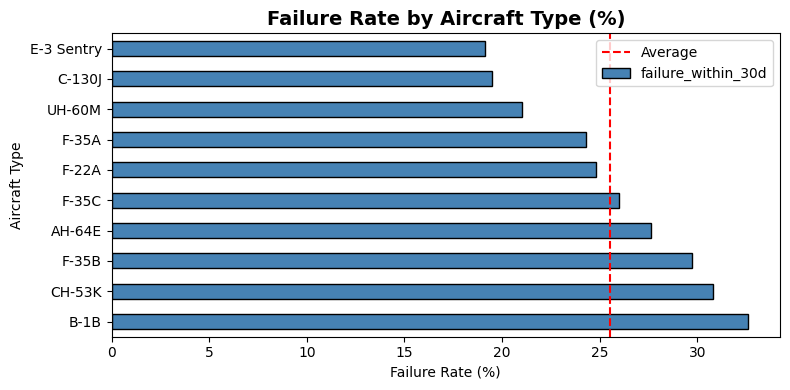

In [116]:
# Step 7: visualization


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
failure_rate.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Failure Rate by Aircraft Type (%)", fontsize=14, fontweight="bold")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Aircraft Type")
plt.axvline(x=failure_rate.mean(), color="red", linestyle="--", label="Average")
plt.legend()
plt.tight_layout()
plt.show()

B-1B, CH-53K, F-35B  → above average (red line) → high risk



F-35A, F-22A, F-35C  → around average



UH-60M, C-130J, E-3  → below average → low risk

4 aircraft types exceed the average failure rate: B-1B, CH-53K, F-35B, and AH-64E. These should be prioritized for preventive maintenance

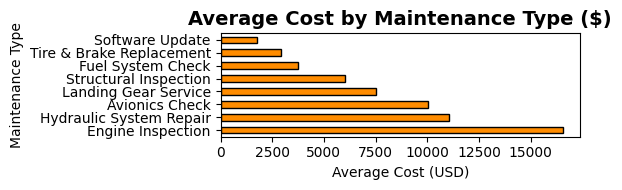

maintenance_type
Engine Inspection           16554.49
Hydraulic System Repair     11031.08
Avionics Check              10011.89
Landing Gear Service         7495.02
Structural Inspection        5996.59
Fuel System Check            3748.16
Tire & Brake Replacement     2924.85
Software Update              1739.84
Name: cost_usd, dtype: float64


In [117]:
# Step 8 : cost analysis chart

cost_by_type = messy_df.groupby("maintenance_type")["cost_usd"].mean().round(2)
cost_by_type = cost_by_type.sort_values(ascending=False)

plt.figure(figsize=(6, 2))
cost_by_type.plot(kind="barh", color="darkorange", edgecolor="black")
plt.title("Average Cost by Maintenance Type ($)", fontsize=14, fontweight="bold")
plt.xlabel("Average Cost (USD)")
plt.ylabel("Maintenance Type")
plt.tight_layout()
plt.show()

print(cost_by_type)

Engine Inspection       → $16,554  most expensive  


Software Update         →  $1,739  cheapest        


Range                   → 9.5x difference between top and bottom

Engine Inspection and Hydraulic System Repair together account for the highest maintenance costs. Optimizing these two job types could significantly reduce overall maintenance budget.

In [118]:
# Step 9 :  which base has most activity
base_df = messy_df.merge(
    aircraft_df[["aircraft_ids", "aircraft_type", "base"]],
    left_on="aircraft_id",
    right_on="aircraft_ids",
    how="left"
)

base_activity = base_df.groupby("base").agg(
    total_jobs   = ("log_id", "count"),
    avg_cost     = ("cost_usd", "mean"),
    failure_rate = ("failure_within_30d", "mean")
).round(2)

base_activity = base_activity.sort_values("total_jobs", ascending=False)
print(base_activity)

                total_jobs  avg_cost  failure_rate
base                                              
Edwards AFB CA       13385   7452.24          0.25
Nellis AFB NV        12095   7433.59          0.25
Langley AFB VA       11559   7414.99          0.25
Hill AFB, UT          6885   7484.16          0.29
Eglin AFB FL          6079   7328.51          0.26


Most jobs    → Edwards AFB, CA                                     (13,385 jobs)


Highest fail → Hill AFB, UT                                         (0.29 = 29%)


Lowest cost  → Eglin AFB, FL                                        ($7,328 avg)

Edwards AFB handles the most maintenance activity at 13,385 jobs, while Hill AFB has the highest failure rate at 29% ,suggesting Hill AFB aircraft may require additional inspection protocols or more experienced technicians

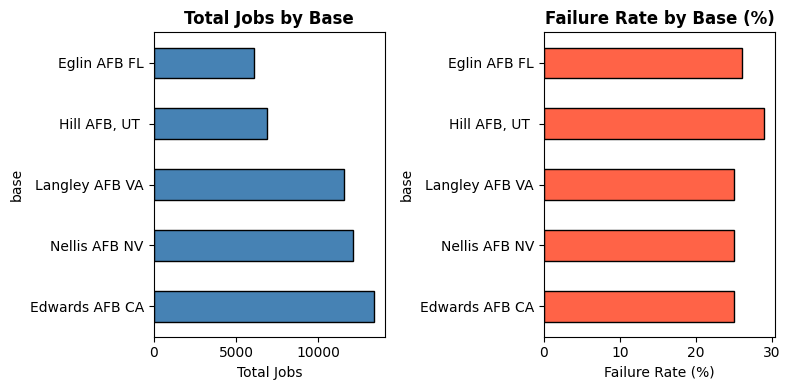

In [119]:
# Step 10 : Visualization

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# chart 1 — total jobs per base
base_activity["total_jobs"].plot(kind="barh", ax=axes[0],
                                  color="steelblue", edgecolor="black")
axes[0].set_title("Total Jobs by Base", fontweight="bold")
axes[0].set_xlabel("Total Jobs")

# chart 2 — failure rate per base
(base_activity["failure_rate"] * 100).plot(kind="barh", ax=axes[1],
                                             color="tomato", edgecolor="black")
axes[1].set_title("Failure Rate by Base (%)", fontweight="bold")
axes[1].set_xlabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

Edwards AFB → busiest base (most jobs)



Hill AFB → highest failure rate (29%)




Eglin AFB → least busy but average failure rate




In [120]:
# Step 11: Correlation

corr_df = base_df[["cost_usd", "duration_hours",
                    "parts_replaced", "failure_within_30d"]].corr().round(3)

print("Correlation matrix:")
print(corr_df)

Correlation matrix:
                    cost_usd  duration_hours  parts_replaced  \
cost_usd               1.000          -0.006          -0.002   
duration_hours        -0.006           1.000          -0.004   
parts_replaced        -0.002          -0.004           1.000   
failure_within_30d    -0.001           0.366          -0.001   

                    failure_within_30d  
cost_usd                        -0.001  
duration_hours                   0.366  
parts_replaced                  -0.001  
failure_within_30d               1.000  


+1.0  → perfect positive relationship
        when X goes up, Y goes up



 0.0  → no relationship at all



-1.0  → perfect negative relationship
        when X goes up, Y goes down

+0.9  → strong positive  (flight hours & wear score)


+0.4  → moderate positive


0.0  → no relationship


-0.4  → moderate negative


-0.9  → strong negative  (maintenance quality & failures)

duration_hours vs failure_within_30d → 0.366 This means when duration hours goes up, failures go up moderately.It even make sense as Longer jobs = more complex = more likely to fail again.



cost_usd vs failure_within_30d → -0.001  Almost zero cost has no relationship with failures. Expensive jobs don't fail more than cheap ones.

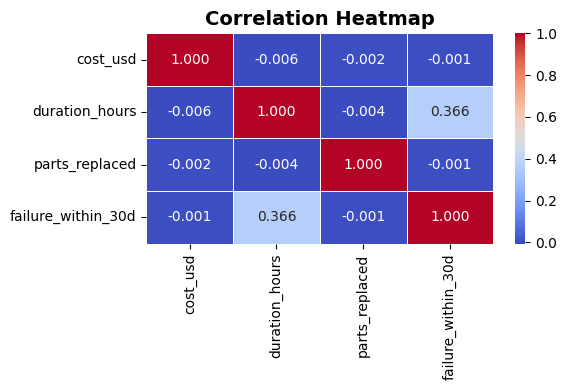

In [121]:
# Step 12: Visulaization

import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(corr_df, annot=True, cmap="coolwarm",
            fmt=".3f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Red    → positive correlation


Blue   → negative correlation


Dark   → strong relationship


Light  → weak relationship

duration_hours ↔ failure_within_30d → 0.366 (moderate positive)


That light red box is your most important finding — longer jobs are moderately linked to failures.


Everything else is near zero — no strong relationships.

**duration_hours is the strongest predictor of failure in our dataset. This will be an important feature in our Random Forest model.**

In [122]:
# Step 13:
messy_df.to_csv("maintenance_logs_analyzed.csv", index=False)
print("Saved!")

Saved!


In [123]:
# Phase 4 — Machine Learning: Failure Prediction

Classification → predicts categories    (yes/no, 0/1, cat/dog)



Regression     → predicts numbers       (price, temperature, cost)

failure_within_30d → 0 or 1 (will it fail? yes or no)

                  → that's a CATEGORY
                  → Classification

cost_usd → $7,437 (a continuous number)


         → Regression

In [124]:
# Step 1: Select Feature
# merge to get wear_score into our main dataframe
model_df = messy_df.merge(
    aircraft_df[["aircraft_ids", "wear_score"]],
    left_on="aircraft_id",
    right_on="aircraft_ids",
    how="left"
)

# X = features (what we have)
X = model_df[["cost_usd", "duration_hours", "parts_replaced", "wear_score"]]

# Y = target (what we predict)
y = model_df["failure_within_30d"]

print("X shape:", X.shape)
print("Y shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 values of Y:")
print(y.head())

X shape: (50003, 4)
Y shape: (50003,)

First 5 rows of X:
   cost_usd  duration_hours  parts_replaced  wear_score
0    9982.0             8.5               3       0.189
1   11213.0            13.4               4       0.424
2    1729.5             5.6               4       0.232
3    4857.0             9.8               7       0.372
4    5792.0            61.3               3       0.385

First 5 values of Y:
0    0
1    0
2    0
3    0
4    1
Name: failure_within_30d, dtype: int64


duration_hours = 61.3  ← very long job


long job = more likely to fail.

In [125]:
# Step 2: Split data into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("\n80% trains the model, 20% tests it")

Training rows: 40002
Testing rows : 10001

80% trains the model, 20% tests it


In [ ]:
# Step 3: Train the Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Number of trees:", model.n_estimators)

In [ ]:
# Step 4:  Evaluate the model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Class 0 = will NOT fail


Class 1 = WILL fail

Precision

Class 0 → 0.78  when model says "won't fail" it's right 78% of time


Class 1 → 0.74  when model says "will fail" it's right 74% of time






Recall:

Class 0 → 0.97  model catches 97% of actual non-failures


Class 1 → 0.24  model only catches 24% of actual failures





Recall for failures is only 24%:


That means out of every 100 aircraft that WILL fail:


Model correctly warns  → 24 aircraft  
Model MISSES           → 76 aircraft






In defense: missing a failure is dangerous and expensive


Why is recall for failures so low?

Class 0 (no failure) → 7,313 rows


Class 1 (failure)    → 2,688 rows







The data is imbalanced: 3x more non-failures than failures. Model learned to predict "won't fail" most of the time because that's usually correct.









In [ ]:
# Step 5 — Feature importance


importance_df = pd.DataFrame({
    "feature"   : X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)

# visualize
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"],
         color="steelblue", edgecolor="black")
plt.title("Feature Importance — What Predicts Failures?",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

duration_hours ↔ failure = 0.366  (strongest correlation)



duration_hours = 39.2% most important feature



Both analysis point to the same finding i.e, longer jobs predict failures better than anything else.


Random Forest model achieved 77% accuracy in predicting aircraft maintenance failures. Duration of maintenance job was the strongest predictor at 39%, followed by cost at 31% and aircraft wear score at 18%